# 🧩 Student Heterogeneous Group Formation

This notebook implements a system to form balanced student teams based on complementary skill profiles. The goal is to create heterogeneous groups where students with different strengths and weaknesses can work together effectively and learn from each other.

## Overview

The system focuses on creating balanced groups across several key skill domains:

- **Soft Skills**: Communication, leadership, teamwork, adaptability
- **Hard Skills**: Technical knowledge, programming, analysis, domain-specific abilities
- **Creativity**: Innovation, idea generation, thinking outside the box
- **Teamwork**: Collaboration, conflict resolution, task coordination

## Approach

1. **Data Preparation**: Load and preprocess student skill profiles
2. **Skill Profile Analysis**: Understand the distribution of skills across the student population
3. **Clustering for Skill Patterns**: Identify common skill patterns among students 
4. **Group Formation Algorithm**: Create heterogeneous groups with complementary skills
5. **Group Analysis**: Evaluate the balance and complementarity of formed groups

In [15]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
from IPython.display import HTML, display
import random
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading and Exploration

First, we'll load the student dataset and explore its structure. The dataset contains student scores across different skill categories.

In [16]:
# Define data path
data_folder = 'data'
student_data_path = os.path.join(data_folder, 'students_train.csv')

# Load the data
def load_student_data(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"✅ Successfully loaded data with {len(df)} student records")
        return df
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        print("Please ensure the data file exists in the specified path.")
        return None
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# Load student data
students_df = load_student_data(student_data_path)

# Display the first few rows if data loaded successfully
if students_df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(students_df.head())
    
    # Show basic dataset information
    print("\nDataset information:")
    print(f"Number of students: {len(students_df)}")
    print(f"Number of features: {len(students_df.columns)}")
    print("\nFeatures:")
    display(pd.DataFrame({'Column Name': students_df.columns, 
                         'Data Type': students_df.dtypes}))
    
    # Check for missing values
    missing = students_df.isnull().sum()
    if missing.sum() > 0:
        print("\nMissing values per column:")
        display(missing[missing > 0])
    else:
        print("\nNo missing values found in the dataset.")

✅ Successfully loaded data with 2880 student records

First 5 rows of the dataset:


,first_name,last_name,hard_skills,soft_skills,teamwork,creativity,class
0,Rym,Mansour,0.62,1.09,4.96,3.15,5NIDS35
1,Mohamed,Jaziri,2.31,1.03,1.52,1.80,5GAMIX57
2,Wassim,Khlifi,1.45,1.85,1.84,3.70,3A69
3,Asma,Karoui,0.32,0.23,4.68,3.45,5TWIN2
4,Adel,Saidi,4.36,4.41,4.32,1.18,5TWIN27



Dataset information:
Number of students: 2880
Number of features: 7

Features:


,Column Name,Data Type
first_name,first_name,object
last_name,last_name,object
hard_skills,hard_skills,float64
soft_skills,soft_skills,float64
teamwork,teamwork,float64
creativity,creativity,float64
class,class,object



No missing values found in the dataset.


Detected skill columns: ['hard_skills', 'soft_skills', 'teamwork', 'creativity']

Summary statistics for skill scores:


,hard_skills,soft_skills,teamwork,creativity
count,2880.000000,2880.000000,2880.000000,2880.000000
mean,2.514337,2.524708,2.476778,2.452531
std,1.437327,1.438085,1.437401,1.427608
min,0.000000,0.000000,0.000000,0.000000
25%,1.280000,1.280000,1.250000,1.230000
50%,2.490000,2.530000,2.490000,2.430000
75%,3.750000,3.810000,3.710000,3.640000
max,5.000000,5.000000,5.000000,5.000000


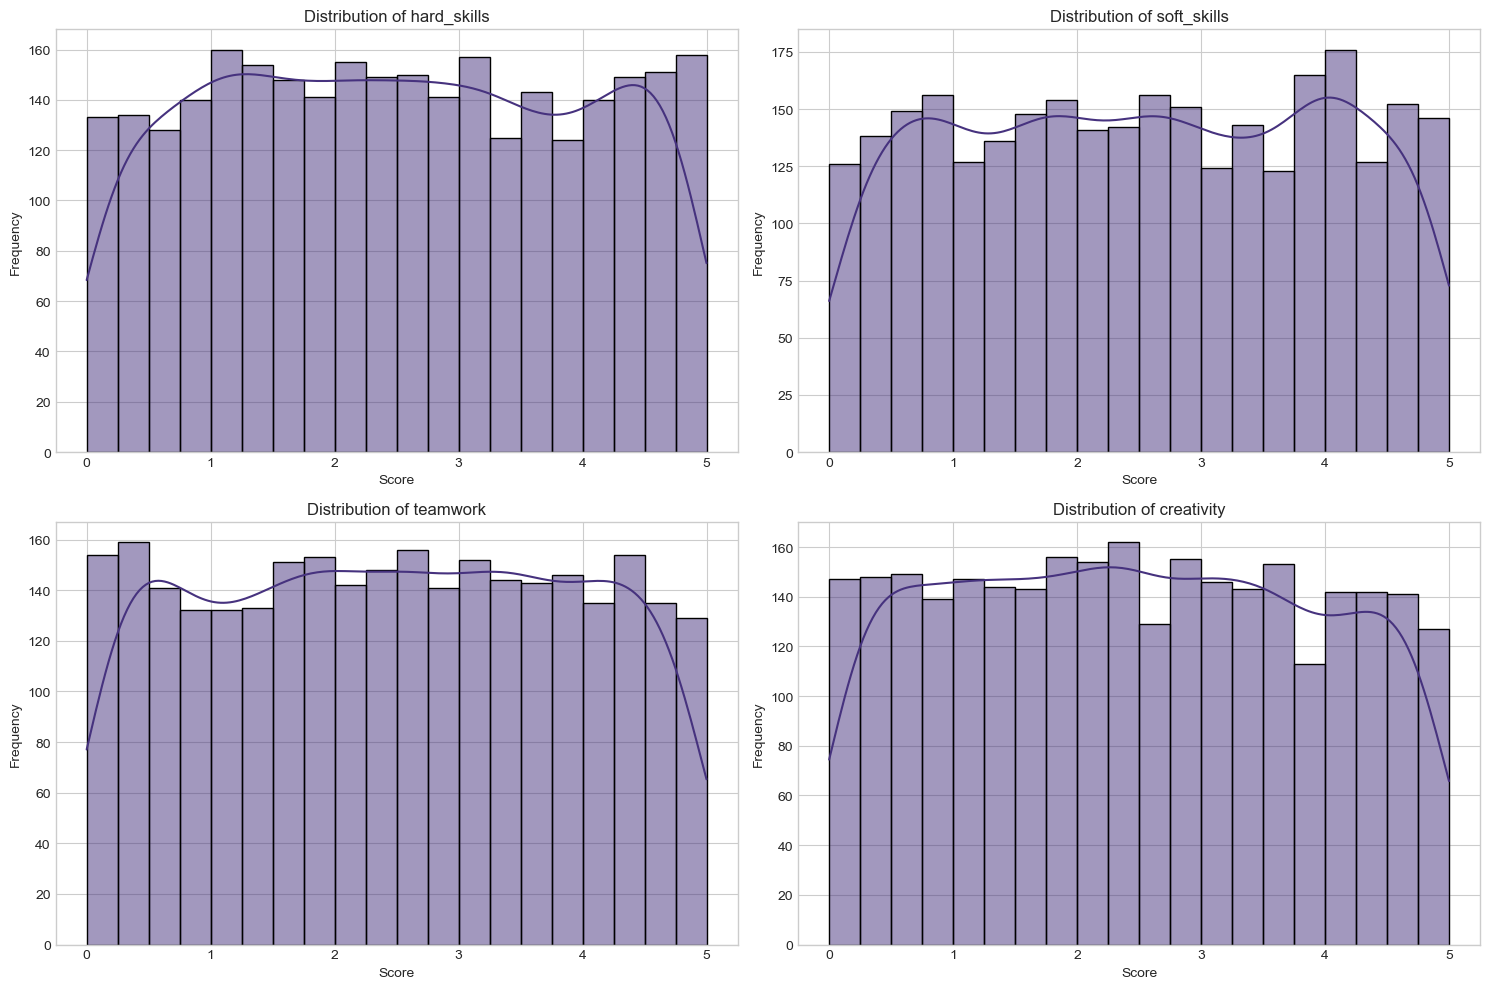

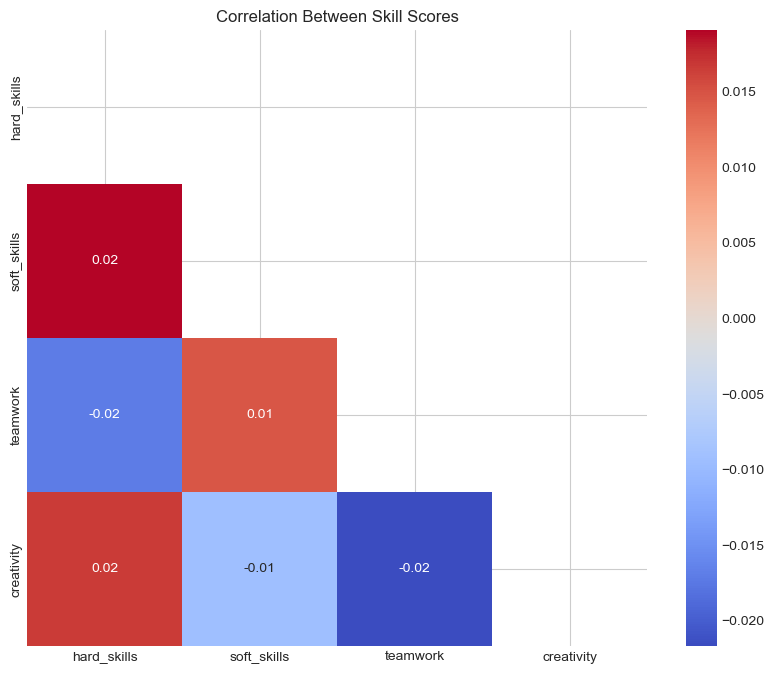

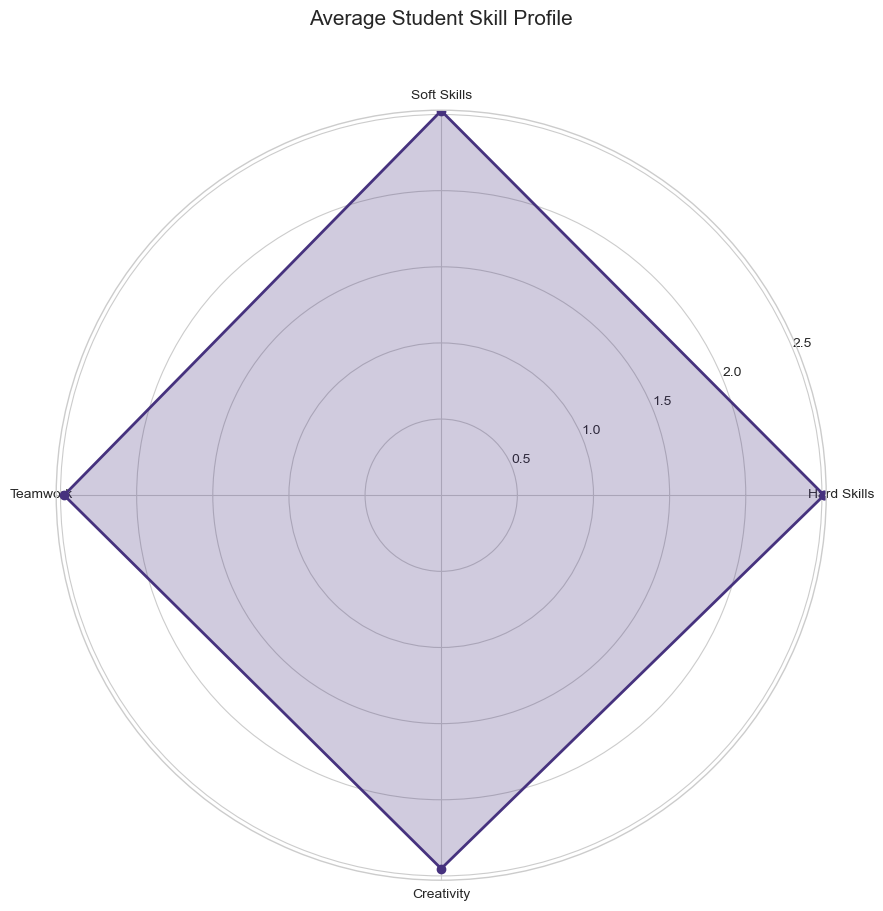

In [17]:
# Explore the distribution of scores
if students_df is not None:
    # Get skill columns (assuming they end with 'skills' or 'score')
    skill_cols = [col for col in students_df.columns if 
                  any(x in col.lower() for x in ['skill', 'score', 'creativity', 'teamwork'])]
    
    if not skill_cols:
        print("No skill columns detected. Please check column naming.")
    else:
        print(f"Detected skill columns: {skill_cols}")
        
        # Display summary statistics
        print("\nSummary statistics for skill scores:")
        display(students_df[skill_cols].describe())
        
        # Create histograms for skill score distributions
        plt.figure(figsize=(15, 10))
        
        for i, col in enumerate(skill_cols, 1):
            plt.subplot(2, (len(skill_cols)+1)//2, i)
            sns.histplot(students_df[col], kde=True, bins=20)
            plt.title(f'Distribution of {col}')
            plt.xlabel('Score')
            plt.ylabel('Frequency')
            
        plt.tight_layout()
        plt.show()
        
        # Create correlation heatmap
        plt.figure(figsize=(10, 8))
        corr = students_df[skill_cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
        plt.title('Correlation Between Skill Scores')
        plt.show()
        
        # Create a radar chart for the average skill profile
        def create_radar_chart(df, skill_columns, title="Skill Profile"):
            # Calculate mean values for each skill
            means = df[skill_columns].mean().values
            
            # For radar chart, we need to close the circle
            values = np.append(means, means[0])
            
            # Create angle values
            N = len(means)
            angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
            angles += angles[:1]  # Close the loop
            
            # Create labels (prettify column names)
            labels = [col.replace('_', ' ').title() for col in skill_columns]
            labels += labels[:1]  # Close the loop
            
            # Create the plot
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(111, polar=True)
            
            # Draw the radar chart
            ax.plot(angles, values, 'o-', linewidth=2)
            ax.fill(angles, values, alpha=0.25)
            
            # Set the labels
            ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
            
            # Beautify
            ax.set_title(title, size=15, y=1.1)
            ax.grid(True)
            
            return fig
        
        # Create radar chart for average student
        radar_fig = create_radar_chart(students_df, skill_cols, "Average Student Skill Profile")
        plt.show()

## 2. Data Preprocessing

Before clustering, we'll preprocess the data to ensure it's suitable for analysis. This includes:
1. Handling missing values (if any)
2. Scaling the features to ensure all skills contribute equally
3. Calculating additional metrics like overall skill level and skill variance

Adding derived features...
  - Added overall_skill (mean of all skills)
  - Added skill_variance (variance across skills)
  - Added dominant_skill (strongest skill area)
  - Added weakest_skill (area needing most development)
Normalizing skill scores...
  - Added normalized versions of all skill columns

Processed data (first 5 rows):


,first_name,last_name,hard_skills,soft_skills,teamwork,creativity,class,overall_skill,skill_variance,dominant_skill,weakest_skill,norm_hard_skills,norm_soft_skills,norm_teamwork,norm_creativity
0,Rym,Mansour,0.62,1.09,4.96,3.15,5NIDS35,2.4550,3.996167,teamwork,hard_skills,0.124,0.218,0.992,0.630
1,Mohamed,Jaziri,2.31,1.03,1.52,1.80,5GAMIX57,1.6650,0.286167,hard_skills,soft_skills,0.462,0.206,0.304,0.360
2,Wassim,Khlifi,1.45,1.85,1.84,3.70,3A69,2.2100,1.021400,creativity,hard_skills,0.290,0.370,0.368,0.740
3,Asma,Karoui,0.32,0.23,4.68,3.45,5TWIN2,2.1700,5.041533,teamwork,soft_skills,0.064,0.046,0.936,0.690
4,Adel,Saidi,4.36,4.41,4.32,1.18,5TWIN27,3.5675,2.534758,soft_skills,creativity,0.872,0.882,0.864,0.236



Summary of derived features:


,overall_skill,skill_variance
count,2880.000000,2880.000000
mean,2.492089,2.059145
std,0.717977,1.247848
min,0.247500,0.000492
25%,1.965000,1.012242
50%,2.505000,1.890363
75%,3.005625,2.954417
max,4.672500,7.275633


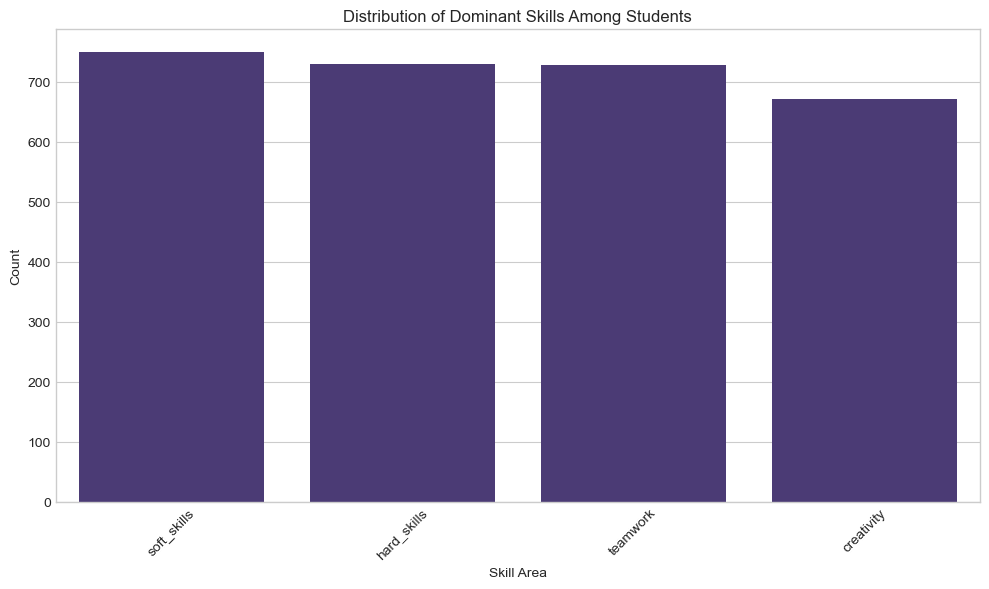

In [18]:
# Preprocess the student data
def preprocess_student_data(df, skill_columns):
    """
    Preprocess student data for clustering.
    
    Args:
        df: DataFrame containing student data
        skill_columns: List of columns containing skill scores
        
    Returns:
        Processed DataFrame ready for clustering
    """
    # Create a copy to avoid modifying the original
    processed_df = df.copy()
    
    # Handle missing values if any
    if processed_df[skill_columns].isnull().sum().sum() > 0:
        print("Handling missing values...")
        # Fill missing values with mean of the column
        for col in skill_columns:
            if processed_df[col].isnull().sum() > 0:
                mean_val = processed_df[col].mean()
                processed_df[col] = processed_df[col].fillna(mean_val)
                print(f"  - Filled missing values in {col} with mean: {mean_val:.2f}")
    
    # Add derived features
    print("Adding derived features...")
    
    # Overall skill level (average across all skills)
    processed_df['overall_skill'] = processed_df[skill_columns].mean(axis=1)
    print(f"  - Added overall_skill (mean of all skills)")
    
    # Skill variance (how specialized or balanced a student is)
    processed_df['skill_variance'] = processed_df[skill_columns].var(axis=1)
    print(f"  - Added skill_variance (variance across skills)")
    
    # Dominant skill area
    processed_df['dominant_skill'] = processed_df[skill_columns].idxmax(axis=1)
    print(f"  - Added dominant_skill (strongest skill area)")
    
    # Weakest skill area
    processed_df['weakest_skill'] = processed_df[skill_columns].idxmin(axis=1)
    print(f"  - Added weakest_skill (area needing most development)")
    
    # Create normalized versions of the skills (0-1 scale)
    print("Normalizing skill scores...")
    scaler = MinMaxScaler()
    normalized_skills = scaler.fit_transform(processed_df[skill_columns])
    
    for i, col in enumerate(skill_columns):
        processed_df[f'norm_{col}'] = normalized_skills[:, i]
        
    print(f"  - Added normalized versions of all skill columns")
    
    return processed_df

# Apply preprocessing if data is loaded
if students_df is not None:
    # Get skill columns
    skill_cols = [col for col in students_df.columns if 
                  any(x in col.lower() for x in ['skill', 'score', 'creativity', 'teamwork'])]
    
    if skill_cols:
        # Preprocess the data
        processed_students = preprocess_student_data(students_df, skill_cols)
        
        # Display the processed data
        print("\nProcessed data (first 5 rows):")
        display(processed_students.head())
        
        # Show summary of derived features
        print("\nSummary of derived features:")
        derived_cols = ['overall_skill', 'skill_variance']
        display(processed_students[derived_cols].describe())
        
        # Display distribution of dominant skills
        plt.figure(figsize=(10, 6))
        dominant_counts = processed_students['dominant_skill'].value_counts()
        sns.barplot(x=dominant_counts.index, y=dominant_counts.values)
        plt.title('Distribution of Dominant Skills Among Students')
        plt.xlabel('Skill Area')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No skill columns identified for preprocessing.")

## 3. Skill Pattern Identification through Clustering

Now we'll identify common patterns in student skill profiles using K-means clustering. This will help us understand different skill archetypes that exist in the student population.

Determining optimal number of clusters...


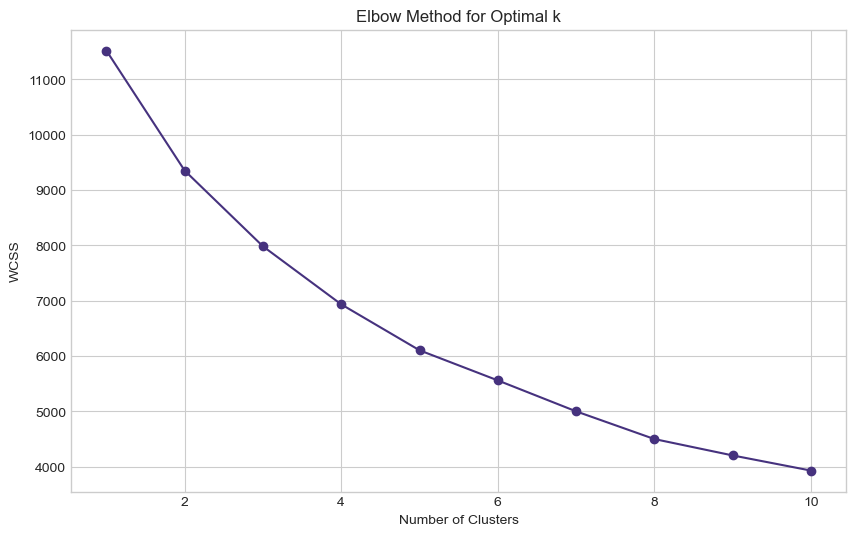

Performing K-means clustering with 4 clusters...
Generating 2D visualization of clusters using PCA...


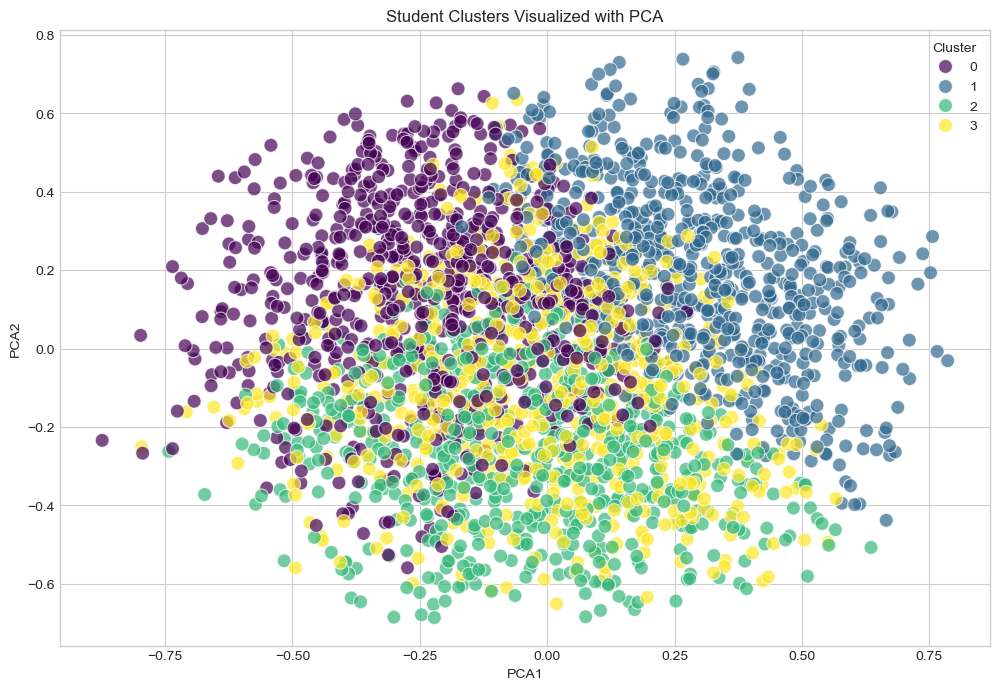

Generating radar charts for each cluster...


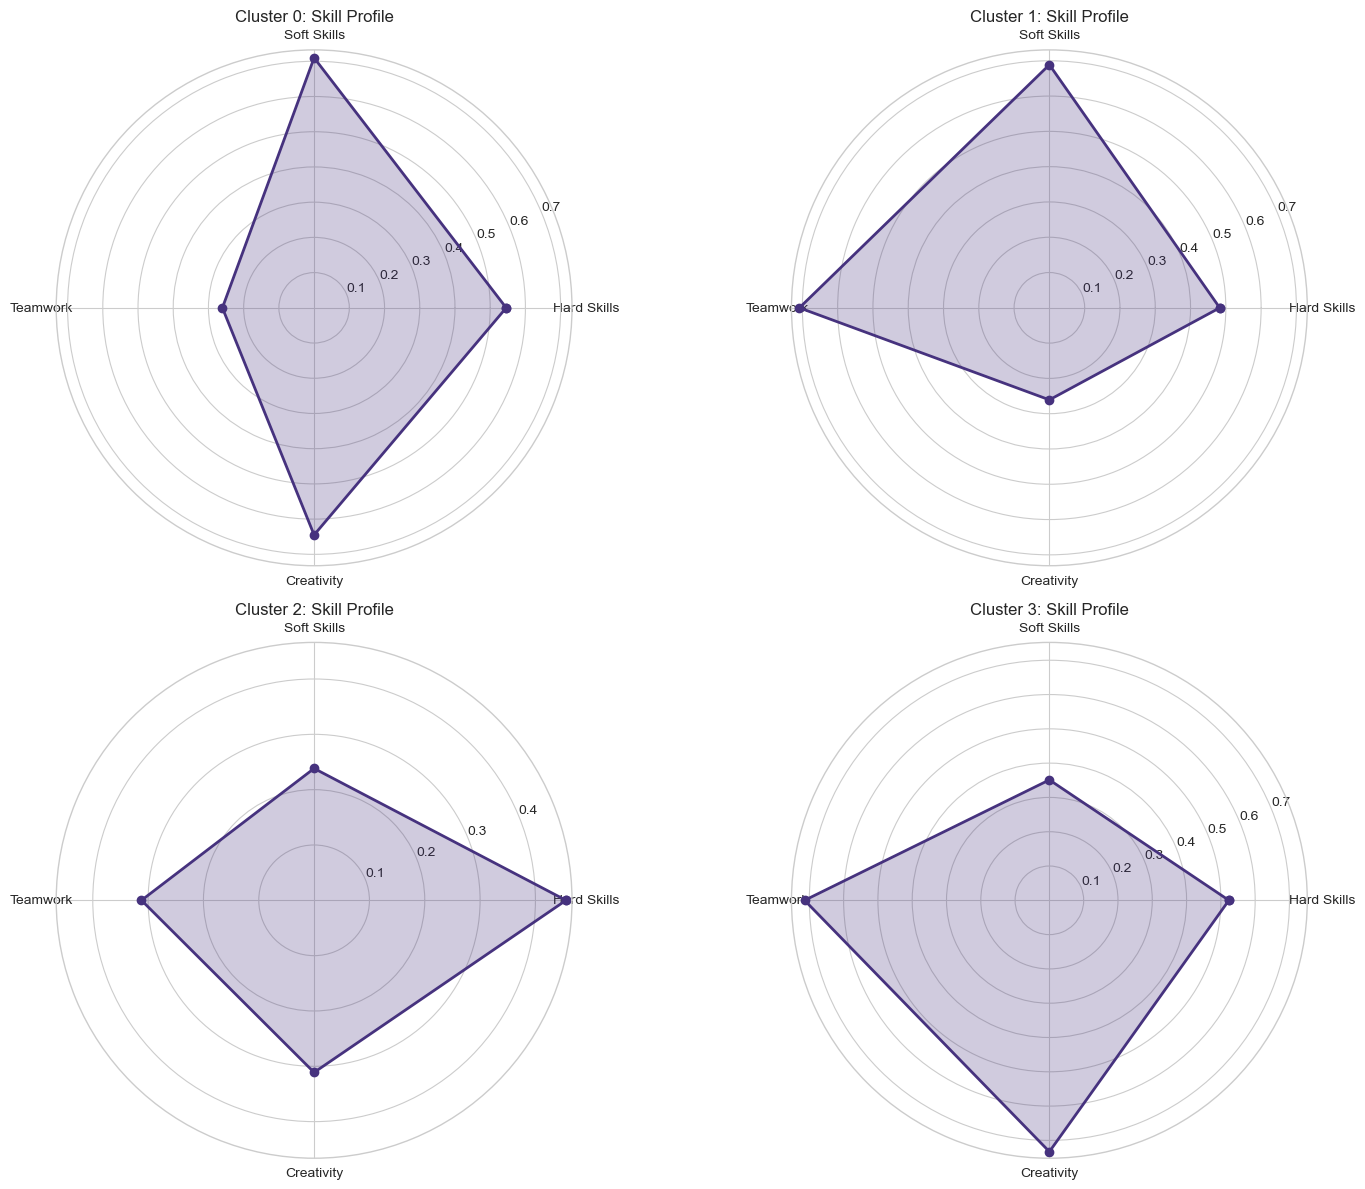

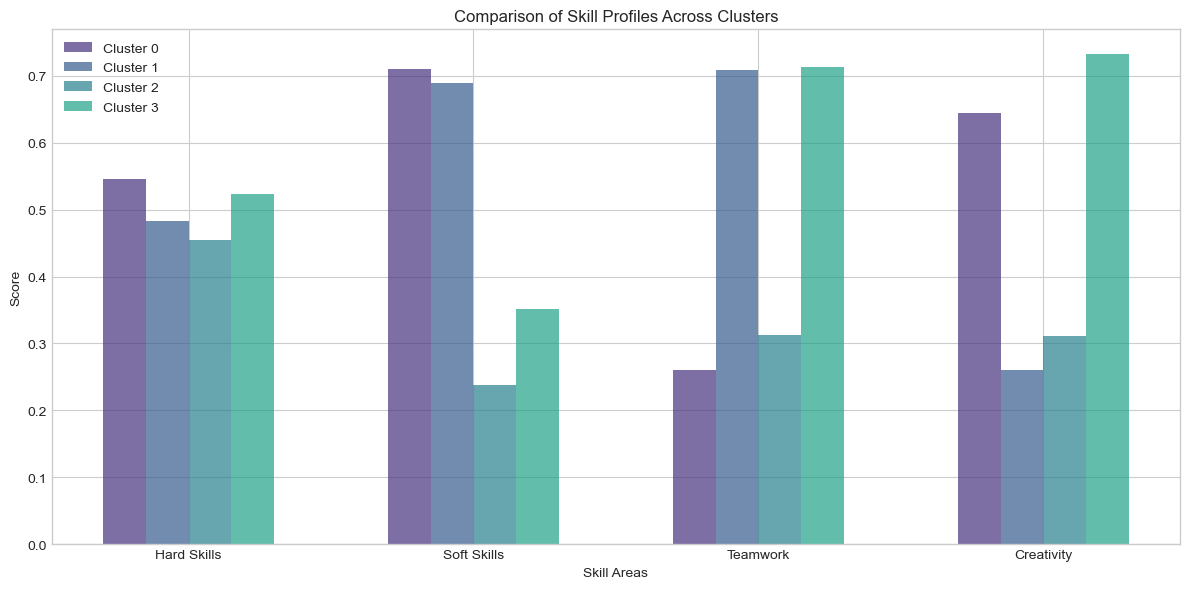


Cluster sizes:
Cluster 0: 771 students (26.8%)
Cluster 1: 722 students (25.1%)
Cluster 2: 686 students (23.8%)
Cluster 3: 701 students (24.3%)

Cluster Profiles:

Cluster 0 - 771 students:
  Strengths: Creativity, Soft Skills
  Needs Development: Teamwork, Hard Skills
  Overall Profile: Hard Skills: 0.55 / Soft Skills: 0.71 / Teamwork: 0.26 / Creativity: 0.64

Cluster 1 - 722 students:
  Strengths: Soft Skills, Teamwork
  Needs Development: Creativity, Hard Skills
  Overall Profile: Hard Skills: 0.48 / Soft Skills: 0.69 / Teamwork: 0.71 / Creativity: 0.26

Cluster 2 - 686 students:
  Strengths: Teamwork, Hard Skills
  Needs Development: Soft Skills, Creativity
  Overall Profile: Hard Skills: 0.46 / Soft Skills: 0.24 / Teamwork: 0.31 / Creativity: 0.31

Cluster 3 - 701 students:
  Strengths: Teamwork, Creativity
  Needs Development: Soft Skills, Hard Skills
  Overall Profile: Hard Skills: 0.52 / Soft Skills: 0.35 / Teamwork: 0.71 / Creativity: 0.73


In [19]:
# Function to perform clustering on student skill profiles
def cluster_student_skills(df, skill_columns, n_clusters=4):
    """
    Cluster students based on their skill profiles.
    
    Args:
        df: Processed DataFrame with student data
        skill_columns: List of columns containing skill scores
        n_clusters: Number of clusters to form
        
    Returns:
        DataFrame with cluster assignments
    """
    # Create a copy to avoid modifying the original
    clustered_df = df.copy()
    
    # Extract features for clustering (normalized skill scores)
    norm_cols = [f'norm_{col}' for col in skill_columns]
    if all(col in clustered_df.columns for col in norm_cols):
        X = clustered_df[norm_cols].values
    else:
        print("Normalized columns not found, using original skill columns")
        X = clustered_df[skill_columns].values
    
    # Scale the data to have mean=0 and variance=1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Determine optimal number of clusters using elbow method
    wcss = []  # Within-Cluster Sum of Squares
    max_clusters = min(10, len(df) - 1)  # Don't try more clusters than data points minus 1
    
    print("Determining optimal number of clusters...")
    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    # Plot elbow method results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='-')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.show()
    
    # Proceed with the specified number of clusters
    print(f"Performing K-means clustering with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    clustered_df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Get cluster centers (in the original scale)
    centers_scaled = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)
    
    # Create a DataFrame for cluster centers
    if all(col in clustered_df.columns for col in norm_cols):
        centers_df = pd.DataFrame(centers_original, columns=norm_cols)
        # Rename columns back to original
        centers_df.columns = [col.replace('norm_', '') for col in centers_df.columns]
    else:
        centers_df = pd.DataFrame(centers_original, columns=skill_columns)
    
    centers_df['cluster'] = range(n_clusters)
    
    return clustered_df, centers_df

# Function to visualize clusters
def visualize_clusters(df, centers_df, skill_columns):
    """
    Create visualizations for the clustering results.
    """
    n_clusters = len(centers_df)
    
    # 1. PCA for 2D visualization
    print("Generating 2D visualization of clusters using PCA...")
    
    # Get normalized feature columns
    norm_cols = [f'norm_{col}' for col in skill_columns]
    if all(col in df.columns for col in norm_cols):
        X = df[norm_cols].values
    else:
        X = df[skill_columns].values
    
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Create a DataFrame for plotting
    pca_df = pd.DataFrame({
        'PCA1': X_pca[:, 0],
        'PCA2': X_pca[:, 1],
        'Cluster': df['cluster']
    })
    
    # Plot the clusters
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100, alpha=0.7)
    plt.title('Student Clusters Visualized with PCA')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()
    
    # 2. Radar charts for each cluster center
    print("Generating radar charts for each cluster...")
    
    # Set up the figure
    fig, axes = plt.subplots(nrows=(n_clusters+1)//2, ncols=2, figsize=(15, 3*n_clusters), 
                             subplot_kw={'polar': True})
    axes = axes.flatten()
    
    # For each cluster, create a radar chart
    for i in range(n_clusters):
        # Get the cluster center
        center = centers_df[centers_df['cluster'] == i][skill_columns].values[0]
        
        # Close the loop for the radar chart
        values = np.append(center, center[0])
        
        # Angles for the radar chart
        angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Labels (prettify column names)
        labels = [col.replace('_', ' ').title() for col in skill_columns]
        labels += labels[:1]  # Close the loop
        
        # Plot the radar chart
        axes[i].plot(angles, values, 'o-', linewidth=2)
        axes[i].fill(angles, values, alpha=0.25)
        axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
        axes[i].set_title(f'Cluster {i}: Skill Profile', size=12)
    
    # Hide any unused subplots
    for i in range(n_clusters, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Bar chart comparing all clusters
    plt.figure(figsize=(12, 6))
    
    # Set width of bars
    bar_width = 0.15
    
    # Set position of bars on x axis
    positions = np.arange(len(skill_columns))
    
    # Plot bars for each cluster
    for i in range(n_clusters):
        center = centers_df[centers_df['cluster'] == i][skill_columns].values[0]
        plt.bar(positions + i*bar_width, center, bar_width, 
                alpha=0.7, label=f'Cluster {i}')
    
    # Add labels and title
    plt.xlabel('Skill Areas')
    plt.ylabel('Score')
    plt.title('Comparison of Skill Profiles Across Clusters')
    plt.xticks(positions + bar_width * (n_clusters-1) / 2, [col.replace('_', ' ').title() for col in skill_columns])
    plt.legend()
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
    
    # 4. Summary statistics for each cluster
    print("\nCluster sizes:")
    cluster_sizes = df['cluster'].value_counts().sort_index()
    for cluster, size in cluster_sizes.items():
        print(f"Cluster {cluster}: {size} students ({size/len(df)*100:.1f}%)")
    
    # 5. Create cluster profile descriptions
    print("\nCluster Profiles:")
    for i in range(n_clusters):
        # Get cluster center
        center = centers_df[centers_df['cluster'] == i][skill_columns].values[0]
        
        # Identify strengths and weaknesses
        strengths = [skill_columns[j] for j in np.argsort(center)[-2:]]
        weaknesses = [skill_columns[j] for j in np.argsort(center)[:2]]
        
        # Create description
        print(f"\nCluster {i} - {cluster_sizes[i]} students:")
        print(f"  Strengths: {', '.join([s.replace('_', ' ').title() for s in strengths])}")
        print(f"  Needs Development: {', '.join([w.replace('_', ' ').title() for w in weaknesses])}")
        print(f"  Overall Profile: {' / '.join([f'{col.replace('_', ' ').title()}: {score:.2f}' for col, score in zip(skill_columns, center)])}")

# Apply clustering if data is processed
if 'processed_students' in locals():
    n_clusters = 4  # Can be adjusted based on domain knowledge or elbow plot
    clustered_students, cluster_centers = cluster_student_skills(processed_students, skill_cols, n_clusters)
    
    # Visualize the clusters
    visualize_clusters(clustered_students, cluster_centers, skill_cols)

## 4. Heterogeneous Group Formation Algorithm

Now that we've identified the different skill patterns among students, we can form heterogeneous groups. The goal is to create groups where students complement each other's strengths and weaknesses.

Forming 720 groups of 4 students each
Using COMPLEMENTARY grouping method: Pairing students with complementary skills
Analysis of 720 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

,hard_skills,soft_skills,teamwork,creativity,group
0,4.6250,4.5900,4.5275,4.3625,0
1,4.3700,4.4200,3.9150,4.3775,1
2,4.1675,4.4475,3.9100,4.4050,2
3,3.9975,4.2950,4.2700,4.1625,3
4,4.4700,4.1625,3.7025,4.2925,4
...,...,...,...,...,...
715,0.6100,0.8300,0.8650,0.8775,715
716,0.7825,0.6800,0.8325,0.7600,716
717,0.9775,0.6850,0.8125,0.4100,717
718,0.4075,0.4975,0.8925,0.6825,718


Creating multiple figures to display 720 groups (showing 10 per figure)


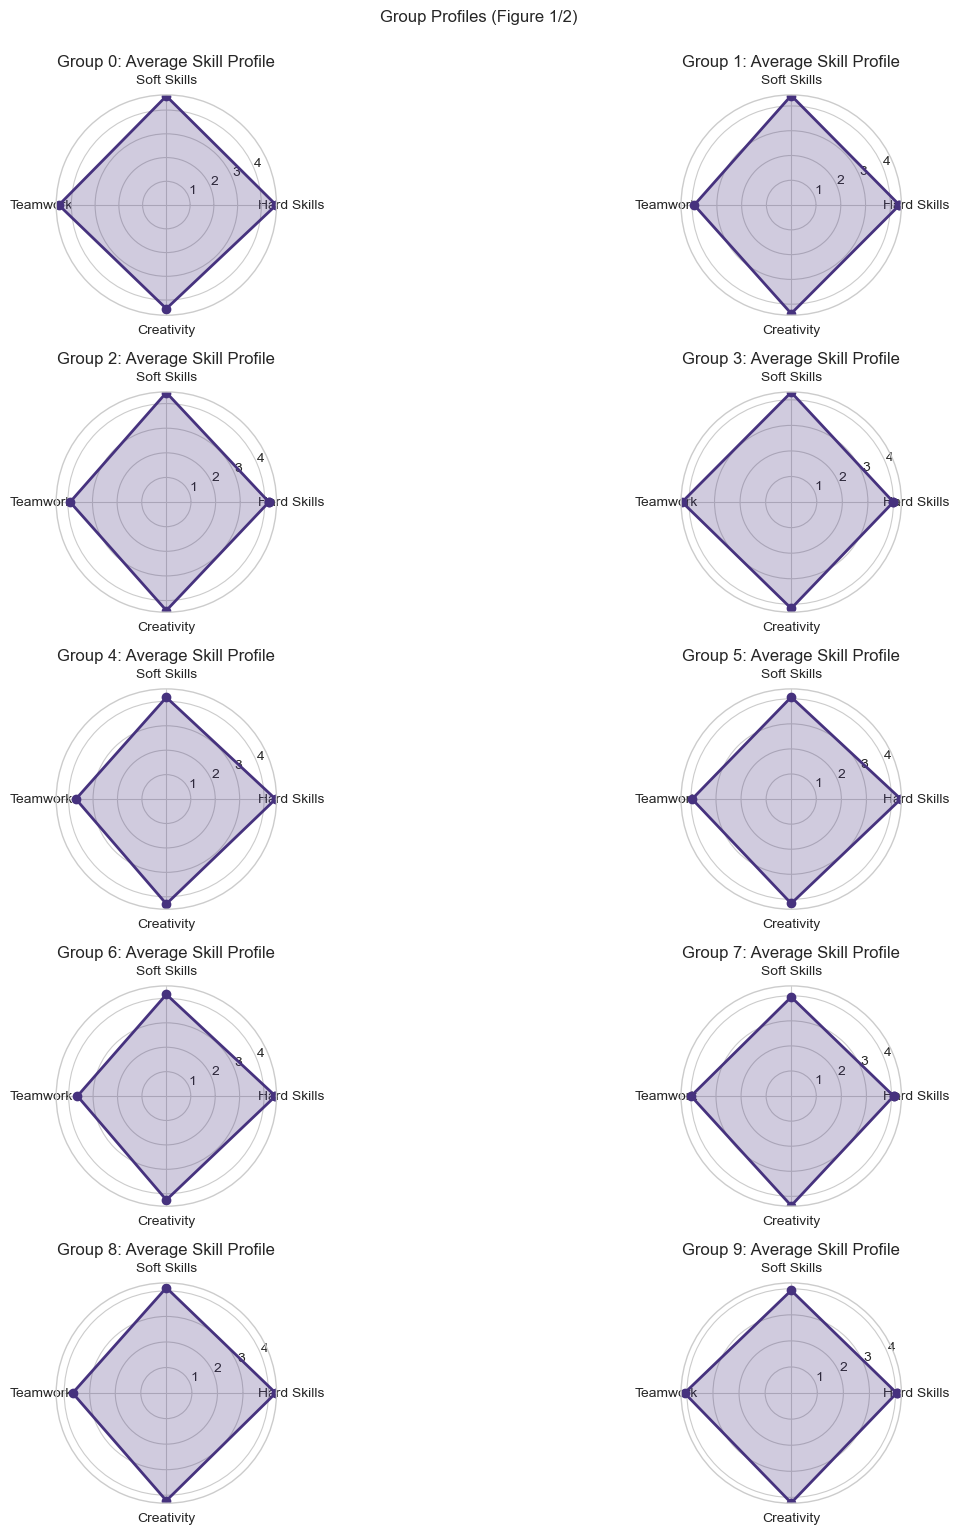

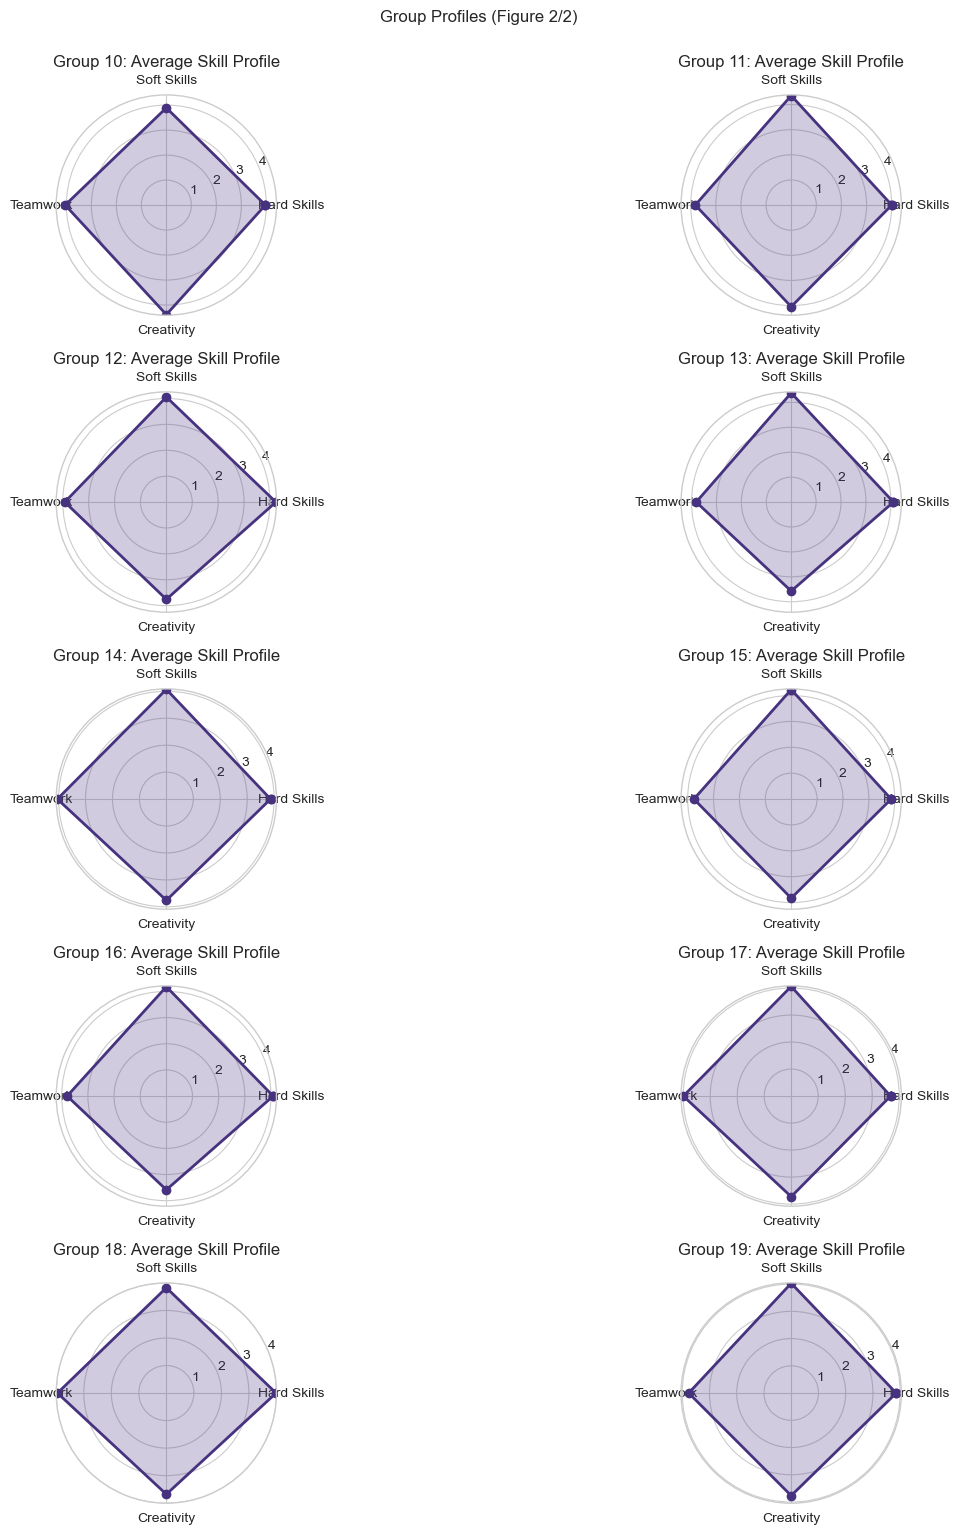

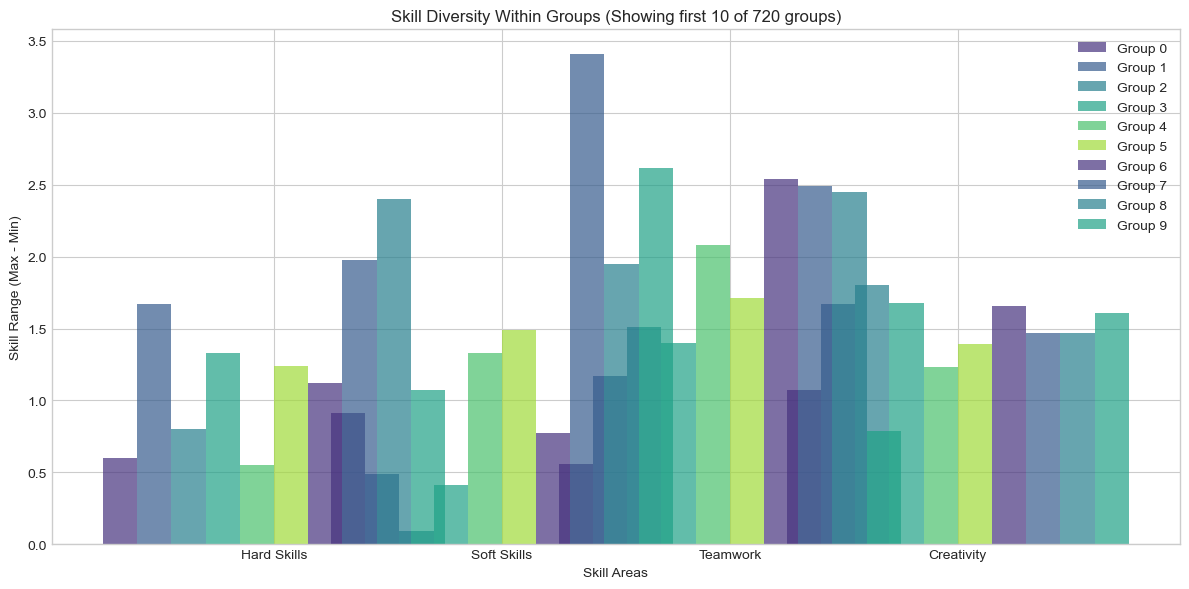


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,4.6250,4.5900,4.5275,4.3625
1,1,4,4.3700,4.4200,3.9150,4.3775
2,2,4,4.1675,4.4475,3.9100,4.4050
3,3,4,3.9975,4.2950,4.2700,4.1625
4,4,4,4.4700,4.1625,3.7025,4.2925
...,...,...,...,...,...,...
715,715,4,0.6100,0.8300,0.8650,0.8775
716,716,4,0.7825,0.6800,0.8325,0.7600
717,717,4,0.9775,0.6850,0.8125,0.4100
718,718,4,0.4075,0.4975,0.8925,0.6825



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 4.62 (Range: 4.30 - 4.90)
    - Soft Skills: 4.59 (Range: 4.00 - 4.91)
    - Teamwork: 4.53 (Range: 4.27 - 4.83)
    - Creativity: 4.36 (Range: 3.71 - 4.78)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
0,4.6725,soft_skills,hard_skills,4.30,4.91,4.70,4.78
1,4.5425,hard_skills,soft_skills,4.90,4.00,4.83,4.44
2,4.5275,soft_skills,teamwork,4.49,4.79,4.31,4.52
3,4.3625,hard_skills,creativity,4.81,4.66,4.27,3.71



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 4.37 (Range: 3.23 - 4.90)
    - Soft Skills: 4.42 (Range: 4.09 - 4.58)
    - Teamwork: 3.91 (Range: 3.28 - 4.45)
    - Creativity: 4.38 (Range: 3.22 - 4.89)

  Group members:


...


Average skill range within groups (higher = more diverse):


hard_skills    2.891069
soft_skills    2.896306
teamwork       2.932083
creativity     2.909722
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 2.91 (higher = more diverse)
- Cross-group skill variation: 0.75 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels

Alternative grouping methods for comparison:

BALANCED method (similar average skill levels):
Forming 720 groups of 4 students each
Using BALANCED grouping method: Ensuring each group has similar average skill levels
Analysis of 720 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

,hard_skills,soft_skills,teamwork,creativity,group
0,3.9850,3.0925,2.6800,2.3900,0
1,3.2925,2.9975,3.3200,2.4075,1
2,2.3700,2.0275,3.8225,3.7825,2
3,4.2450,2.5000,2.0300,3.0575,3
4,1.6100,3.1350,3.4300,3.6125,4
...,...,...,...,...,...
715,0.7175,2.7075,2.8650,1.7500,715
716,1.5475,1.7175,2.6150,2.1500,716
717,1.5825,1.8925,2.3650,2.1400,717
718,1.1025,2.2925,2.2800,2.0725,718


Creating multiple figures to display 720 groups (showing 10 per figure)


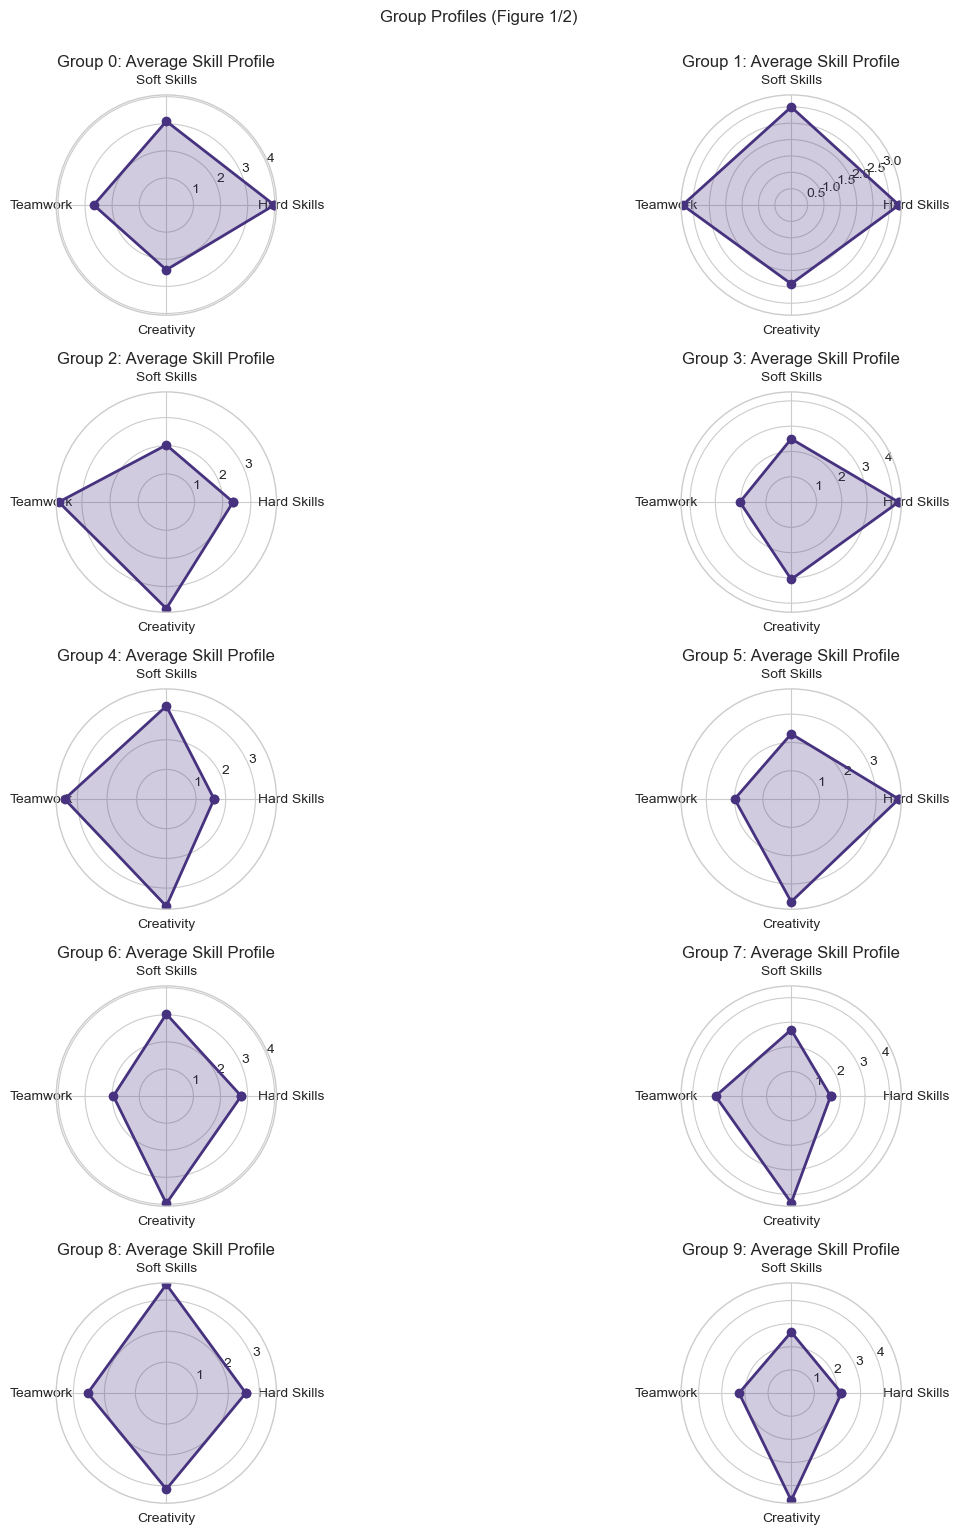

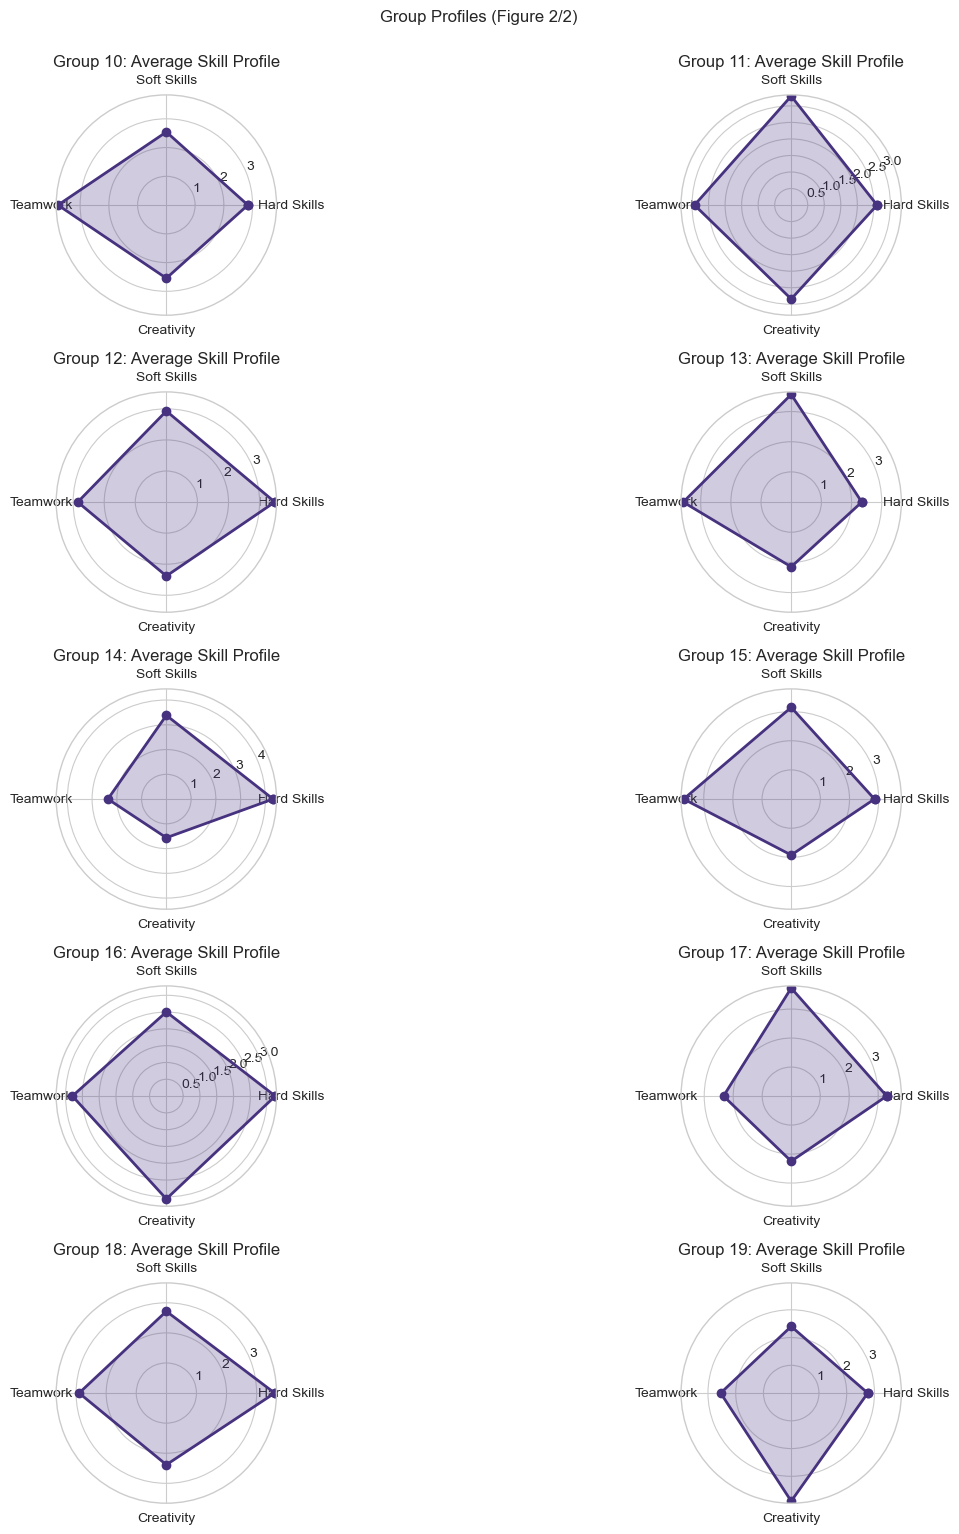

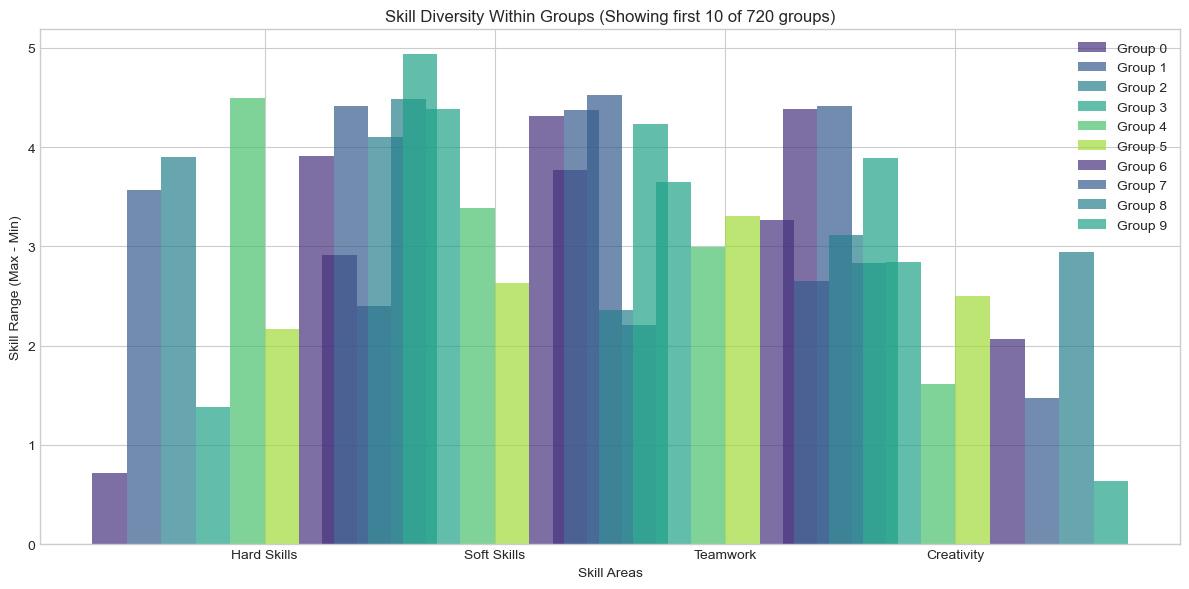


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,3.9850,3.0925,2.6800,2.3900
1,1,4,3.2925,2.9975,3.3200,2.4075
2,2,4,2.3700,2.0275,3.8225,3.7825
3,3,4,4.2450,2.5000,2.0300,3.0575
4,4,4,1.6100,3.1350,3.4300,3.6125
...,...,...,...,...,...,...
715,715,4,0.7175,2.7075,2.8650,1.7500
716,716,4,1.5475,1.7175,2.6150,2.1500
717,717,4,1.5825,1.8925,2.3650,2.1400
718,718,4,1.1025,2.2925,2.2800,2.0725



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 3.98 (Range: 3.58 - 4.30)
    - Soft Skills: 3.09 (Range: 2.00 - 4.91)
    - Teamwork: 2.68 (Range: 0.93 - 4.70)
    - Creativity: 2.39 (Range: 0.40 - 4.78)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
0,4.6725,soft_skills,hard_skills,4.30,4.91,4.70,4.78
720,3.0050,teamwork,creativity,3.97,2.51,4.11,1.43
1440,2.5050,hard_skills,teamwork,4.09,2.00,0.98,2.95
2160,1.9650,hard_skills,creativity,3.58,2.95,0.93,0.40



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 3.29 (Range: 1.33 - 4.90)
    - Soft Skills: 3.00 (Range: 1.60 - 4.00)
    - Teamwork: 3.32 (Range: 0.30 - 4.83)
    - Creativity: 2.41 (Range: 0.02 - 4.44)

  Group members:


...


Average skill range within groups (higher = more diverse):


hard_skills    3.046764
soft_skills    3.124819
teamwork       3.061417
creativity     3.036750
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 3.07 (higher = more diverse)
- Cross-group skill variation: 0.66 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels

MIXED method (cluster-based assignment):
Forming 720 groups of 4 students each
Using MIXED grouping method: Combining cluster-based and skill-based assignment
Analysis of 720 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

,hard_skills,soft_skills,teamwork,creativity,group
0,4.6600,3.8625,3.9350,3.5825,0
1,4.7650,3.5900,3.6900,3.6650,1
2,4.4750,3.5800,3.5700,3.9375,2
3,4.3125,3.7675,3.6900,3.4725,3
4,4.0475,3.7275,3.6850,3.6425,4
...,...,...,...,...,...
715,0.3775,2.8275,1.4050,1.7575,715
716,0.5850,3.3400,1.5925,0.8000,716
717,0.3975,3.0200,1.0025,1.7200,717
718,0.7325,3.1900,1.2425,0.7500,718


Creating multiple figures to display 720 groups (showing 10 per figure)


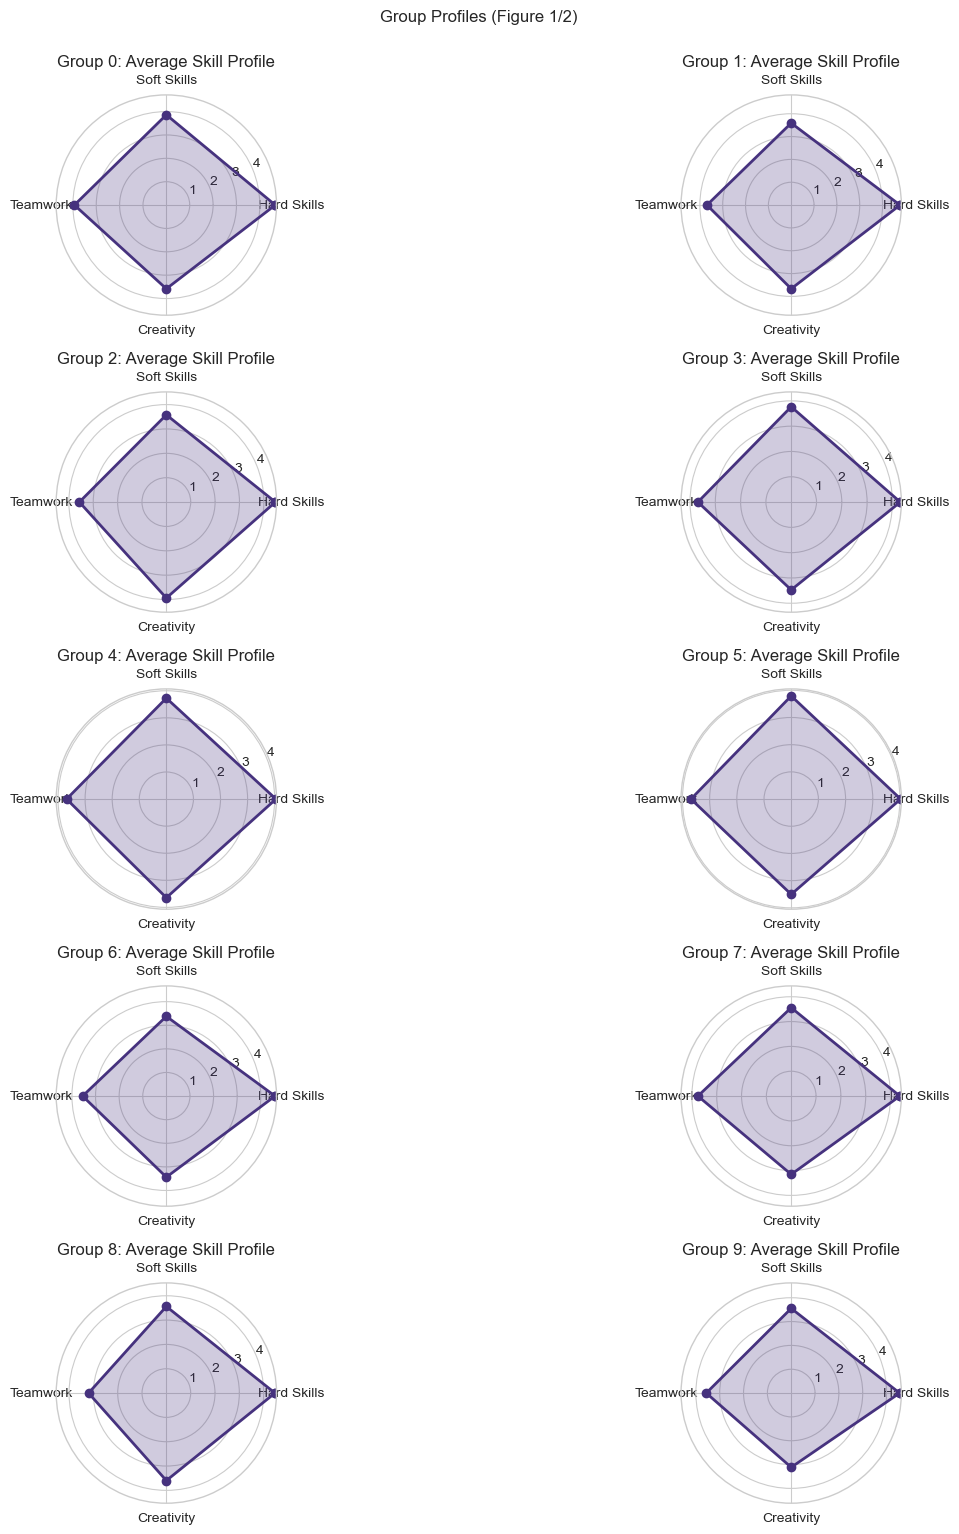

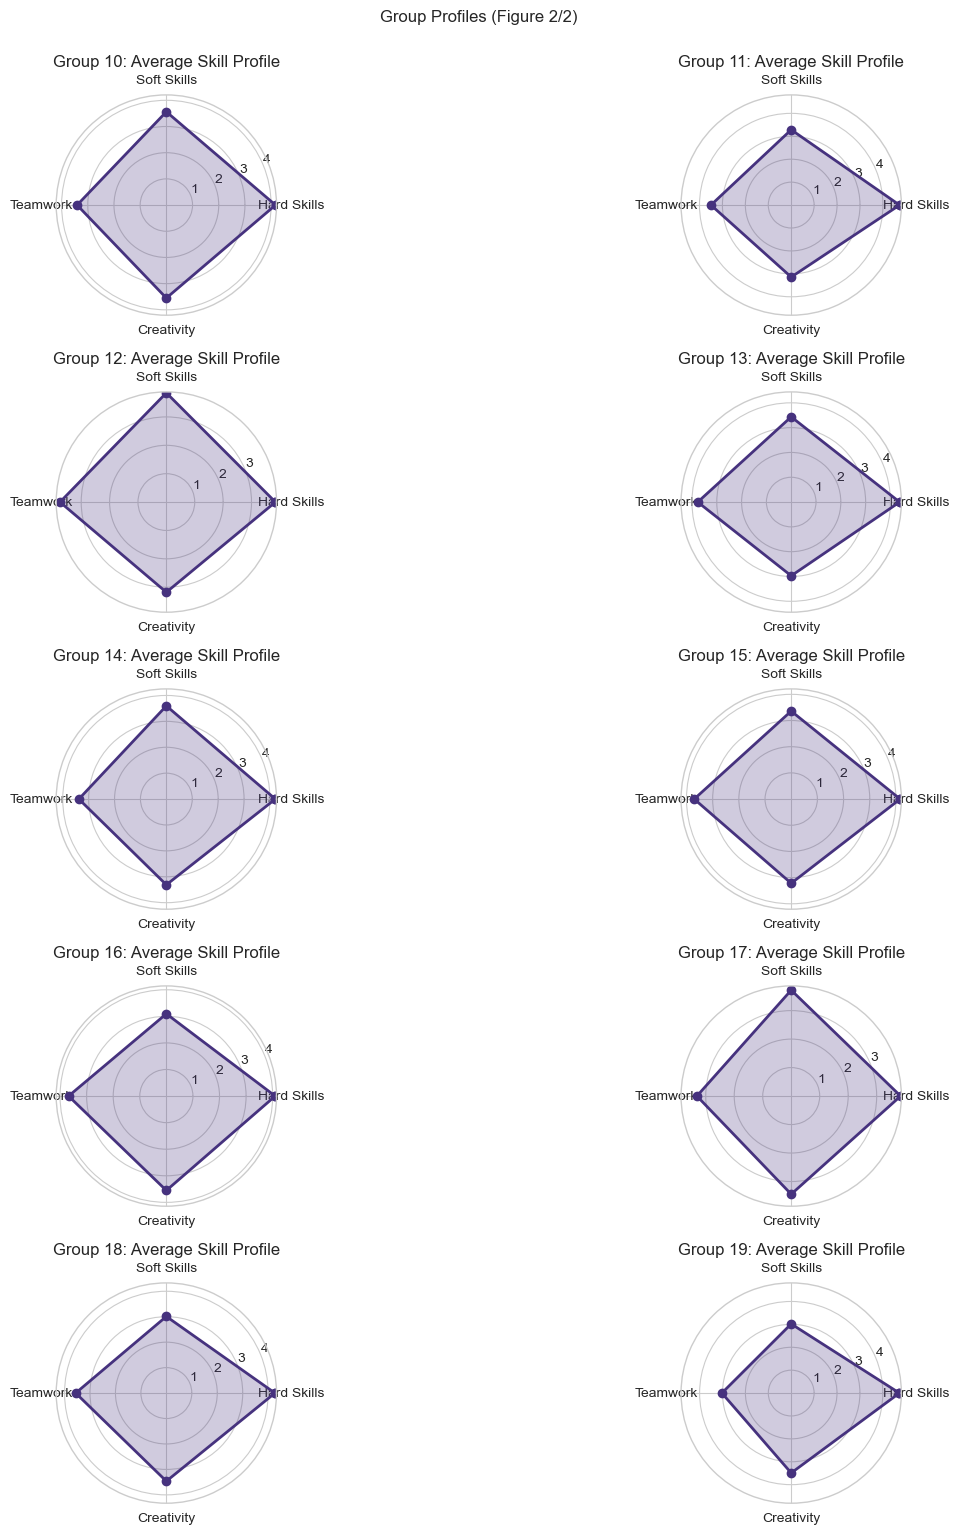

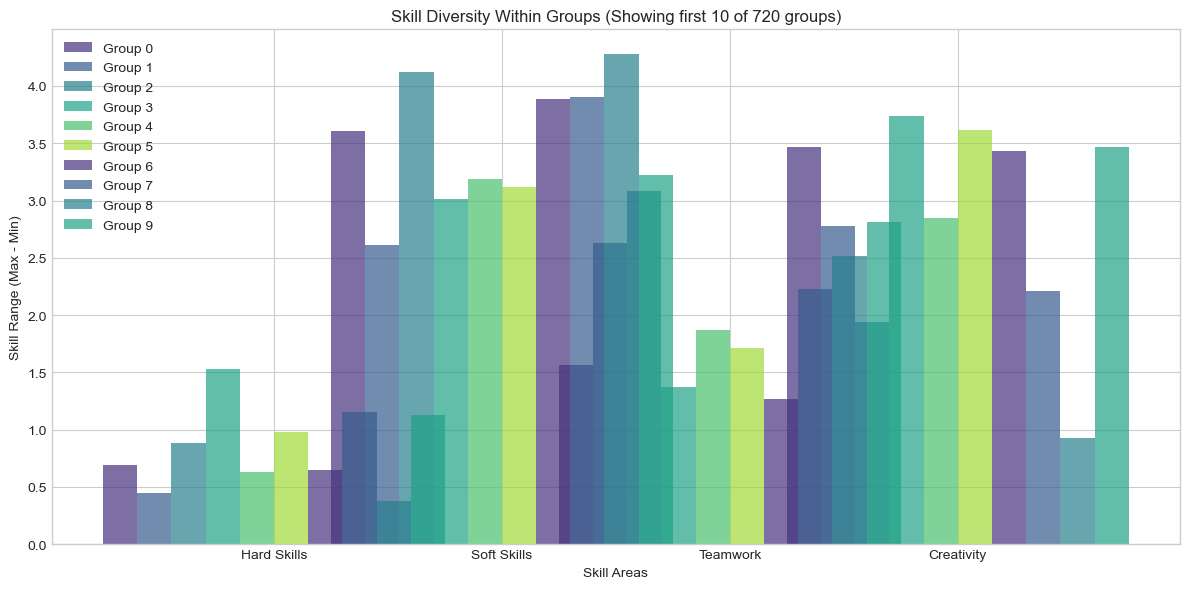


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,4.6600,3.8625,3.9350,3.5825
1,1,4,4.7650,3.5900,3.6900,3.6650
2,2,4,4.4750,3.5800,3.5700,3.9375
3,3,4,4.3125,3.7675,3.6900,3.4725
4,4,4,4.0475,3.7275,3.6850,3.6425
...,...,...,...,...,...,...
715,715,4,0.3775,2.8275,1.4050,1.7575
716,716,4,0.5850,3.3400,1.5925,0.8000
717,717,4,0.3975,3.0200,1.0025,1.7200
718,718,4,0.7325,3.1900,1.2425,0.7500



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 4.66 (Range: 4.30 - 4.99)
    - Soft Skills: 3.86 (Range: 1.30 - 4.91)
    - Teamwork: 3.93 (Range: 3.14 - 4.70)
    - Creativity: 3.58 (Range: 1.31 - 4.78)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
1365,4.3200,soft_skills,teamwork,4.54,4.58,3.63,4.53
1532,4.3625,hard_skills,creativity,4.81,4.66,4.27,3.71
2840,2.6850,hard_skills,soft_skills,4.99,1.30,3.14,1.31
2716,4.6725,soft_skills,hard_skills,4.30,4.91,4.70,4.78



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 4.77 (Range: 4.45 - 4.90)
    - Soft Skills: 3.59 (Range: 1.83 - 4.44)
    - Teamwork: 3.69 (Range: 2.20 - 4.83)
    - Creativity: 3.67 (Range: 2.11 - 4.89)

  Group members:


...


--------------------------------------------------------------------------------

... and 715 more groups (not shown in detail)
Use the summary table above to see average skill levels for all groups.

Group balance analysis:
Standard deviation of average skill levels across groups:


hard_skills    1.020919
soft_skills    0.594578
teamwork       0.628144
creativity     0.579171
dtype: float64


Average skill range within groups (higher = more diverse):


hard_skills    2.364486
soft_skills    3.160472
teamwork       3.085597
creativity     3.162389
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 2.94 (higher = more diverse)
- Cross-group skill variation: 0.71 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels


In [20]:
# Function to form heterogeneous student groups
def form_heterogeneous_groups(df, skill_columns, group_size=4, method='complementary'):
    """
    Form heterogeneous student groups with complementary skills.
    
    Args:
        df: DataFrame with student data and cluster assignments
        skill_columns: List of skill columns
        group_size: Target size for each group
        method: Method for forming groups ('complementary', 'balanced', or 'mixed')
    
    Returns:
        Dictionary of groups and their member information
    """
    # Create a working copy
    students = df.copy()
    
    # Shuffle the students to ensure randomness in selection
    students = students.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Calculate number of groups
    n_students = len(students)
    n_groups = n_students // group_size
    remainder = n_students % group_size
    
    print(f"Forming {n_groups} groups of {group_size} students each", end="")
    if remainder > 0:
        print(f" (with {remainder} remaining students)")
    else:
        print()
        
    # Initialize groups
    groups = {}
    
    if method == 'complementary':
        print("Using COMPLEMENTARY grouping method: Pairing students with complementary skills")
        
        # Sort students by overall skill level
        students = students.sort_values('overall_skill', ascending=False).reset_index(drop=True)
        
        # For each group, select students with diverse skill strengths
        for g in range(n_groups):
            group_members = []
            
            # Start with students that have different dominant skills
            remaining_students = students[~students.index.isin([m for group in groups.values() for m in group])]
            
            # Select first student (highest overall skill not yet assigned)
            if len(remaining_students) > 0:
                first_student_idx = remaining_students.index[0]
                group_members.append(first_student_idx)
                first_student = remaining_students.loc[first_student_idx]
                
                # Find students with complementary skills
                for _ in range(1, group_size):
                    if len(remaining_students) <= 1:
                        break
                        
                    # Remove already selected students
                    remaining_students = students[~students.index.isin([m for group in groups.values() for m in group] + group_members)]
                    
                    if len(remaining_students) == 0:
                        break
                        
                    # Create a compatibility score - higher for students with strengths
                    # where the current group is weak
                    compatibility_scores = []
                    
                    # Get current group skill profile
                    current_group_skills = students.loc[group_members, skill_columns].mean()
                    
                    for idx, student in remaining_students.iterrows():
                        # Calculate how complementary this student is to the current group
                        # High score if student is strong where group is weak
                        comp_score = 0
                        for skill in skill_columns:
                            # Weighted difference - give higher importance to skills where group is weak
                            weight = 1 + (5 - current_group_skills[skill]) / 5
                            comp_score += weight * (student[skill] - current_group_skills[skill])
                            
                        compatibility_scores.append((idx, comp_score))
                    
                    # Sort by compatibility score (higher is better)
                    compatibility_scores.sort(key=lambda x: x[1], reverse=True)
                    
                    # Add most compatible student to the group
                    if compatibility_scores:
                        group_members.append(compatibility_scores[0][0])
            
            # Store the group
            if group_members:
                groups[g] = group_members
        
    elif method == 'balanced':
        print("Using BALANCED grouping method: Ensuring each group has similar average skill levels")
        
        # Calculate average skill for each student
        students['avg_skill'] = students[skill_columns].mean(axis=1)
        
        # Sort by average skill
        students = students.sort_values('avg_skill', ascending=False).reset_index(drop=True)
        
        # Distribute students so each group has mix of high, medium, and low performers
        for g in range(n_groups):
            group_members = []
            
            # Select one student from each quartile
            for q in range(group_size):
                pos = g + (q * n_groups)
                if pos < len(students):
                    group_members.append(students.index[pos])
            
            groups[g] = group_members
            
    elif method == 'mixed':
        print("Using MIXED grouping method: Combining cluster-based and skill-based assignment")
        
        # Get number of clusters
        n_clusters = students['cluster'].nunique()
        
        # For each group, try to include students from different clusters
        for g in range(n_groups):
            group_members = []
            
            # Try to add one student from each cluster
            for c in range(min(n_clusters, group_size)):
                cluster_students = students[(students['cluster'] == c) & 
                                           (~students.index.isin([m for group in groups.values() for m in group]))]
                
                if len(cluster_students) > 0:
                    # Take the student with highest overall_skill from this cluster
                    student_idx = cluster_students.sort_values('overall_skill', ascending=False).index[0]
                    group_members.append(student_idx)
            
            # If we need more students to reach group_size
            remaining_spots = group_size - len(group_members)
            if remaining_spots > 0:
                # Get remaining students
                remaining_students = students[~students.index.isin([m for group in groups.values() for m in group] + group_members)]
                
                # Sort by overall skill (descending)
                remaining_students = remaining_students.sort_values('overall_skill', ascending=False)
                
                # Add top students
                for i in range(min(remaining_spots, len(remaining_students))):
                    group_members.append(remaining_students.index[i])
            
            groups[g] = group_members
    
    else:
        raise ValueError(f"Unknown grouping method: {method}")
    
    # Handle remaining students by adding them to existing groups
    remaining_students = students[~students.index.isin([m for group in groups.values() for m in group])]
    
    for i, idx in enumerate(remaining_students.index):
        if i < len(groups):
            groups[i].append(idx)
    
    # Convert group indices to actual student data
    groups_data = {}
    for g, member_indices in groups.items():
        group_df = students.loc[member_indices].copy()
        groups_data[g] = {
            'members': group_df,
            'size': len(group_df),
            'avg_skills': group_df[skill_columns].mean().to_dict(),
            'min_skills': group_df[skill_columns].min().to_dict(),
            'max_skills': group_df[skill_columns].max().to_dict(),
            'skill_range': (group_df[skill_columns].max() - group_df[skill_columns].min()).to_dict()
        }
    
    return groups_data

# Function to analyze and visualize the formed groups
def analyze_groups(groups, skill_columns):
    """
    Analyze and visualize the formed groups.
    """
    n_groups = len(groups)
    print(f"Analysis of {n_groups} formed groups:")
    
    # 1. Summary statistics for all groups
    group_sizes = [data['size'] for data in groups.values()]
    print(f"Group sizes: {group_sizes}")
    
    # Create a DataFrame with group averages
    group_avgs = pd.DataFrame([data['avg_skills'] for data in groups.values()])
    group_avgs['group'] = list(groups.keys())
    
    # Calculate skill ranges in each group
    group_ranges = pd.DataFrame([data['skill_range'] for data in groups.values()])
    group_ranges['group'] = list(groups.keys())
    
    # Display average skill profiles for each group
    print("\nAverage skill profiles for each group:")
    display(group_avgs)
    
    # 2. Radar charts for group average profiles
    # Limit the number of charts to avoid excessive figure size
    max_groups_to_display = min(n_groups, 20)  # Display at most 20 groups to avoid memory issues
    
    if max_groups_to_display <= 10:
        # For a small number of groups, display all in one figure
        fig_rows = (max_groups_to_display + 1) // 2
        fig, axes = plt.subplots(nrows=fig_rows, ncols=min(2, max_groups_to_display), 
                               figsize=(15, 3*fig_rows), subplot_kw={'polar': True})
        
        # Handle the case of a single subplot
        if max_groups_to_display == 1:
            axes = np.array([axes])
        
        # Ensure axes is always a flattened array
        axes = np.atleast_1d(axes).flatten()
        
        for i, (group_id, data) in enumerate(list(groups.items())[:max_groups_to_display]):
            # Get the group's average skill profile
            avg_profile = [data['avg_skills'][skill] for skill in skill_columns]
            
            # Close the loop for the radar chart
            values = np.append(avg_profile, avg_profile[0])
            
            # Angles for the radar chart
            angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
            angles += angles[:1]  # Close the loop
            
            # Labels (prettify column names)
            labels = [col.replace('_', ' ').title() for col in skill_columns]
            labels += labels[:1]  # Close the loop
            
            # Plot the radar chart
            axes[i].plot(angles, values, 'o-', linewidth=2)
            axes[i].fill(angles, values, alpha=0.25)
            axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
            axes[i].set_title(f'Group {group_id}: Average Skill Profile', size=12)
        
        # Hide any unused subplots
        for i in range(max_groups_to_display, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        # For many groups, create multiple figures with at most 10 groups each
        print(f"Creating multiple figures to display {n_groups} groups (showing 10 per figure)")
        
        for fig_num, group_offset in enumerate(range(0, max_groups_to_display, 10)):
            groups_in_figure = min(10, max_groups_to_display - group_offset)
            fig_rows = (groups_in_figure + 1) // 2
            
            fig, axes = plt.subplots(nrows=fig_rows, ncols=min(2, groups_in_figure), 
                                   figsize=(15, 3*fig_rows), subplot_kw={'polar': True})
            
            # Ensure axes is always a flattened array
            axes = np.atleast_1d(axes).flatten()
            
            for i in range(groups_in_figure):
                group_index = group_offset + i
                group_id = list(groups.keys())[group_index]
                data = groups[group_id]
                
                # Get the group's average skill profile
                avg_profile = [data['avg_skills'][skill] for skill in skill_columns]
                
                # Close the loop for the radar chart
                values = np.append(avg_profile, avg_profile[0])
                
                # Angles for the radar chart
                angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
                angles += angles[:1]  # Close the loop
                
                # Labels (prettify column names)
                labels = [col.replace('_', ' ').title() for col in skill_columns]
                labels += labels[:1]  # Close the loop
                
                # Plot the radar chart
                axes[i].plot(angles, values, 'o-', linewidth=2)
                axes[i].fill(angles, values, alpha=0.25)
                axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
                axes[i].set_title(f'Group {group_id}: Average Skill Profile', size=12)
            
            # Hide any unused subplots
            for i in range(groups_in_figure, len(axes)):
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.suptitle(f'Group Profiles (Figure {fig_num+1}/{(max_groups_to_display+9)//10})', y=1.02)
            plt.show()
    
    # 3. Skill range within groups (max - min)
    # Limit the number of groups to display in the bar chart
    max_groups_to_plot = min(10, n_groups)  # Display at most 10 groups in the bar chart
    
    plt.figure(figsize=(12, 6))
    
    # Set width of bars
    bar_width = 0.15
    
    # Set position of bars on x axis
    positions = np.arange(len(skill_columns))
    
    # Plot bars for each group's skill range (limited to max_groups_to_plot)
    for i, group_id in enumerate(list(groups.keys())[:max_groups_to_plot]):
        ranges = [groups[group_id]['skill_range'][skill] for skill in skill_columns]
        plt.bar(positions + i*bar_width, ranges, bar_width, 
                alpha=0.7, label=f'Group {group_id}')
    
    # Add labels and title
    plt.xlabel('Skill Areas')
    plt.ylabel('Skill Range (Max - Min)')
    plt.title(f'Skill Diversity Within Groups (Showing first {max_groups_to_plot} of {n_groups} groups)')
    plt.xticks(positions + bar_width * (min(max_groups_to_plot, n_groups)-1) / 2, 
               [col.replace('_', ' ').title() for col in skill_columns])
    
    # Only show legend if there are not too many groups
    if max_groups_to_plot <= 10:
        plt.legend()
    else:
        plt.legend().set_visible(False)
        
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
    
    # 4. Detailed group profiles
    print("\nDetailed group profiles:")
    
    # Limit the number of groups to display in detail
    max_groups_to_display_detail = min(5, n_groups)  # Display details for at most 5 groups
    
    # Create summary table for all groups
    summary_data = []
    for group_id, data in groups.items():
        group_summary = {'Group ID': group_id, 'Size': data['size']}
        # Add average scores for each skill
        for skill in skill_columns:
            group_summary[f'Avg {skill.replace("_", " ").title()}'] = data['avg_skills'][skill]
        summary_data.append(group_summary)
    
    # Display summary table for all groups
    print("\nSummary of all groups:")
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    # Display detailed information for a limited number of groups
    print(f"\nDetailed profiles for first {max_groups_to_display_detail} groups:")
    
    for group_id in list(groups.keys())[:max_groups_to_display_detail]:
        data = groups[group_id]
        print(f"\nGroup {group_id} ({data['size']} members):")
        print("  Average skill profile:")
        for skill in skill_columns:
            print(f"    - {skill.replace('_', ' ').title()}: {data['avg_skills'][skill]:.2f} (Range: {data['min_skills'][skill]:.2f} - {data['max_skills'][skill]:.2f})")
        
        # Print group members
        print("\n  Group members:")
        member_df = data['members'][['overall_skill', 'dominant_skill', 'weakest_skill'] + skill_columns]
        display(member_df)
        print("\n" + "-"*80)
    
    # If there are more groups than we're displaying in detail
    if n_groups > max_groups_to_display_detail:
        print(f"\n... and {n_groups - max_groups_to_display_detail} more groups (not shown in detail)")
        print(f"Use the summary table above to see average skill levels for all groups.")
    
    # 5. Group balance analysis
    print("\nGroup balance analysis:")
    
    # Calculate standard deviation across groups for each skill
    group_std = pd.DataFrame([data['avg_skills'] for data in groups.values()]).std()
    print("Standard deviation of average skill levels across groups:")
    display(group_std)
    
    # Calculate average skill range within groups
    avg_range = group_ranges[skill_columns].mean()
    print("\nAverage skill range within groups (higher = more diverse):")
    display(avg_range)
    
    # Overall assessment
    print("\nOverall group heterogeneity assessment:")
    avg_range_score = avg_range.mean()
    cross_group_std = group_std.mean()
    
    print(f"- Average within-group skill diversity: {avg_range_score:.2f} (higher = more diverse)")
    print(f"- Cross-group skill variation: {cross_group_std:.2f} (lower = more balanced)")
    
    if avg_range_score > 1.5:
        print("✅ Groups have good internal diversity (complementary skills)")
    else:
        print("⚠️ Groups may have limited internal diversity")
        
    if cross_group_std < 0.5:
        print("✅ Groups have similar average skill levels (fair distribution)")
    else:
        print("⚠️ There may be imbalance between group average skill levels")

# Apply group formation if we have clustered data
if 'clustered_students' in locals():
    # Form groups using the complementary method
    student_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                              group_size=4, method='complementary')
    
    # Analyze the formed groups
    analyze_groups(student_groups, skill_cols)
    
    # Also form groups using alternative methods for comparison
    print("\n" + "="*80)
    print("Alternative grouping methods for comparison:")
    
    print("\n" + "="*80)
    print("BALANCED method (similar average skill levels):")
    balanced_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                             group_size=4, method='balanced')
    analyze_groups(balanced_groups, skill_cols)
    
    print("\n" + "="*80)
    print("MIXED method (cluster-based assignment):")
    mixed_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                          group_size=4, method='mixed')
    analyze_groups(mixed_groups, skill_cols)

## 5. Group Project Recommendations

Based on the groups formed and their skill compositions, we can provide recommendations for project types or roles that might be well-suited for each group.

In [21]:
# Function to generate project recommendations for groups
def recommend_projects_and_roles(groups, skill_columns):
    """
    Generate project type and role recommendations for each group.
    """
    print("Generating group project recommendations and role suggestions...")
    
    # Project types based on group skill profiles
    project_types = {
        'high_technical': "Technical development project requiring strong hard skills",
        'high_creative': "Innovation-focused project requiring creative problem solving",
        'high_teamwork': "Complex collaborative project requiring effective team coordination",
        'high_soft_skills': "Client-facing project requiring strong communication and leadership",
        'balanced': "Multifaceted project requiring balanced application of various skills"
    }
    
    # Define role templates
    role_templates = {
        'technical_lead': "Technical implementation and problem-solving",
        'creative_director': "Idea generation and innovative solutions", 
        'team_coordinator': "Task management and team coordination",
        'client_liaison': "Client communication and presentation"
    }
    
    for group_id, data in groups.items():
        print(f"\nGroup {group_id} - Recommendations:")
        
        # Get group average skills
        avg_skills = data['avg_skills']
        
        # Determine group's overall strength
        top_skill = max(avg_skills, key=avg_skills.get)
        top_skill_score = avg_skills[top_skill]
        
        # Determine if the group is balanced or has a clear strength
        skill_values = list(avg_skills.values())
        skill_std = np.std(skill_values)
        
        # Recommend project type
        if skill_std < 0.5:  # Balanced group
            recommended_project = project_types['balanced']
            print(f"📋 Recommended Project Type: {recommended_project}")
            print("   This group has a balanced skill profile and should handle diverse project requirements well.")
        else:  # Group with specific strengths
            if 'hard_skills' in avg_skills and avg_skills['hard_skills'] > 4:
                recommended_project = project_types['high_technical']
            elif 'creativity' in avg_skills and avg_skills['creativity'] > 4:
                recommended_project = project_types['high_creative']
            elif 'teamwork' in avg_skills and avg_skills['teamwork'] > 4:
                recommended_project = project_types['high_teamwork']
            elif 'soft_skills' in avg_skills and avg_skills['soft_skills'] > 4:
                recommended_project = project_types['high_soft_skills']
            else:
                recommended_project = project_types['balanced']
                
            print(f"📋 Recommended Project Type: {recommended_project}")
            print(f"   This group shows particular strength in {top_skill.replace('_', ' ').title()} ({top_skill_score:.2f}/5)")
        
        # Suggest roles for each group member based on individual strengths
        print("\n   Suggested role assignments:")
        
        for i, (idx, student) in enumerate(data['members'].iterrows(), 1):
            # Find student's top skill
            student_skills = {skill: student[skill] for skill in skill_columns}
            top_student_skill = max(student_skills, key=student_skills.get)
            
            # Assign role based on top skill
            if 'hard_skills' in student_skills and top_student_skill == 'hard_skills':
                role = role_templates['technical_lead']
            elif 'creativity' in student_skills and top_student_skill == 'creativity':
                role = role_templates['creative_director']
            elif 'teamwork' in student_skills and top_student_skill == 'teamwork':
                role = role_templates['team_coordinator']
            elif 'soft_skills' in student_skills and top_student_skill == 'soft_skills':
                role = role_templates['client_liaison']
            else:
                # Determine role based on relative strengths
                if 'student_id' in student:
                    student_name = f"Student {student['student_id']}"
                else:
                    student_name = f"Student {idx}"
                
                strengths = []
                if student.get('hard_skills', 0) > 3.5:
                    strengths.append('technical')
                if student.get('creativity', 0) > 3.5:
                    strengths.append('creative')
                if student.get('teamwork', 0) > 3.5:
                    strengths.append('teamwork')
                if student.get('soft_skills', 0) > 3.5:
                    strengths.append('communication')
                
                if not strengths:
                    strengths = ['supportive']
                    
                role = f"General support with focus on {', '.join(strengths)} tasks"
            
            # Print the role suggestion
            if 'student_id' in student:
                student_name = f"Student {student['student_id']}"
            elif 'name' in student:
                student_name = student['name']
            else:
                student_name = f"Student {idx}"
                
            print(f"   - {student_name}: {role} (Strength: {top_student_skill.replace('_', ' ').title()})")
        
        print(f"\n   Key development areas for this group:")
        # Identify the group's weakest skill
        weakest_skill = min(avg_skills, key=avg_skills.get)
        print(f"   - Focus on developing {weakest_skill.replace('_', ' ').title()} ({avg_skills[weakest_skill]:.2f}/5)")
        
        # Additional recommendations based on skill distribution
        if skill_std > 1.0:
            print(f"   - Be aware of significant skill disparities within the group")
            print(f"   - Consider peer mentoring for knowledge sharing")
        
        # Identify if there are any critical gaps (all members weak in same area)
        critical_gaps = []
        for skill in skill_columns:
            if data['max_skills'][skill] < 3.0:  # No one in group is strong in this area
                critical_gaps.append(skill)
                
        if critical_gaps:
            print(f"   - Critical gaps: No team member is strong in {', '.join([g.replace('_', ' ').title() for g in critical_gaps])}")
            print(f"   - Consider seeking external support or focused training in these areas")

# Generate recommendations if we have formed groups
if 'student_groups' in locals():
    recommend_projects_and_roles(student_groups, skill_cols)

Generating group project recommendations and role suggestions...

Group 0 - Recommendations:
📋 Recommended Project Type: Multifaceted project requiring balanced application of various skills
   This group has a balanced skill profile and should handle diverse project requirements well.

   Suggested role assignments:
   - Student 0: Client communication and presentation (Strength: Soft Skills)
   - Student 1: Technical implementation and problem-solving (Strength: Hard Skills)
   - Student 2: Client communication and presentation (Strength: Soft Skills)
   - Student 3: Technical implementation and problem-solving (Strength: Hard Skills)

   Key development areas for this group:
   - Focus on developing Creativity (4.36/5)

Group 1 - Recommendations:
📋 Recommended Project Type: Multifaceted project requiring balanced application of various skills
   This group has a balanced skill profile and should handle diverse project requirements well.

   Suggested role assignments:
   - Student 4

## 6. Exporting Results

Finally, let's export the formed groups and their analysis to a format that can be easily shared and referenced.

In [22]:
# Function to export groups to CSV
def export_groups_to_csv(groups, output_folder='data', filename='student_groups.csv'):
    """
    Export the formed groups to a CSV file.
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Create output path
    output_path = os.path.join(output_folder, filename)
    
    # Create a list to store all group data
    all_group_data = []
    
    for group_id, data in groups.items():
        # Add group ID to each student record
        group_df = data['members'].copy()
        group_df['group_id'] = group_id
        
        # Add to the list
        all_group_data.append(group_df)
    
    # Combine all groups
    if all_group_data:
        combined_df = pd.concat(all_group_data, ignore_index=True)
        
        # Save to CSV
        combined_df.to_csv(output_path, index=False)
        print(f"✅ Exported group assignments to: {output_path}")
        
        return output_path
    else:
        print("❌ No group data to export")
        return None

# Export the groups if we have them
if 'student_groups' in locals():
    export_path = export_groups_to_csv(student_groups)
    
    if export_path:
        # Display a sample of the exported data
        exported_df = pd.read_csv(export_path)
        print("\nSample of exported group assignments:")
        display(exported_df.head())

✅ Exported group assignments to: data\student_groups.csv

Sample of exported group assignments:


,first_name,last_name,hard_skills,soft_skills,teamwork,creativity,class,overall_skill,skill_variance,dominant_skill,weakest_skill,norm_hard_skills,norm_soft_skills,norm_teamwork,norm_creativity,cluster,group_id
0,Ines,Karoui,4.30,4.91,4.70,4.78,3B4,4.6725,0.069158,soft_skills,hard_skills,0.860,0.982,0.940,0.956,3,0
1,Amine,Ferjani,4.90,4.00,4.83,4.44,2A32,4.5425,0.171758,hard_skills,soft_skills,0.980,0.800,0.966,0.888,3,0
2,Adel,Driss,4.49,4.79,4.31,4.52,5SLEAM19,4.5275,0.039225,soft_skills,teamwork,0.898,0.958,0.862,0.904,3,0
3,Leila,Ghanouchi,4.81,4.66,4.27,3.71,3B12,4.3625,0.241025,hard_skills,creativity,0.962,0.932,0.854,0.742,1,0
4,Khalil,Abidi,4.54,4.58,3.63,4.53,3B93,4.3200,0.212067,soft_skills,teamwork,0.908,0.916,0.726,0.906,0,1


## 7. Summary and Conclusion

This notebook has demonstrated a systematic approach to creating heterogeneous student groups with complementary skills. The approach follows these key steps:

1. **Data Analysis**: Explored student skill profiles to understand the distribution and relationship between different skill areas.

2. **Skill Pattern Identification**: Used clustering to identify common patterns in student skill profiles.

3. **Heterogeneous Group Formation**: Created balanced groups where students complement each other's strengths and weaknesses.

4. **Group Analysis**: Evaluated the balance and diversity of skills within each formed group.

5. **Project Recommendations**: Provided tailored project and role recommendations based on group composition.

The heterogeneous grouping approach offers several benefits:
- Students can learn from peers with different strengths
- Groups have more balanced overall capabilities
- Skill gaps in individuals can be compensated for by other team members
- Students get exposure to different perspectives and working styles

This approach can be adapted and refined based on specific educational objectives and additional student characteristics.